<a href="https://colab.research.google.com/github/tomasbelak24/deeplearning-vision/blob/main/hw1/augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Dropout and Augmentation (4pt)

Test the dropout so that it is first only in the fully connected layer (p = 0.5) and then also after the convolutional layers (p = 0.2). And one more option. Remember to use Dropout2d instead of Dropout1d when using in convolution layers.

Test augmentation for 3 different settings. You can be creative, but it should at least make sense. Documentation can be found [here](https://pytorch.org/vision/stable/transforms.html). Be careful to do it right.

Test both things for two cases in one you use a regular split on train/val and in the other you leave only the first 1000 examples in the training set. Be aware that the number of training steps is smaller for the second case, so use proportionately more epochs.

In [1]:
!mkdir -p baseline
# I might make the repo private in the future so the files from /baseline directory from the zip file might have to be used
!wget -O baseline/baseline_model.pth https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/models/baseline_model.pth
!wget -O baseline/baseline_results.json https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/results/baseline_results.json


--2025-11-12 19:47:19--  https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/models/baseline_model.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 381333 (372K) [application/octet-stream]
Saving to: ‘baseline/baseline_model.pth’

baseline/baseline_m 100%[===================>] 372.40K  --.-KB/s    in 0.02s   

2025-11-12 19:47:19 (16.3 MB/s) - ‘baseline/baseline_model.pth’ saved [381333/381333]

--2025-11-12 19:47:19--  https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/results/baseline_results.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443.

In [2]:
import json

with open('baseline/baseline_results.json', 'r') as f:
    baseline_results = json.load(f)

baseline_train_losses = baseline_results['train_losses']
baseline_val_losses = baseline_results['val_losses']
baseline_val_accs = baseline_results['val_accuracies']

print("Baseline results loaded successfully.")

Baseline results loaded successfully.


In [3]:
import torch
import torchvision
import torchvision.transforms as transforms

import numpy as np
from matplotlib import pyplot as plt

100%|██████████| 170M/170M [00:04<00:00, 42.4MB/s]


torch.Size([1, 3, 32, 32])


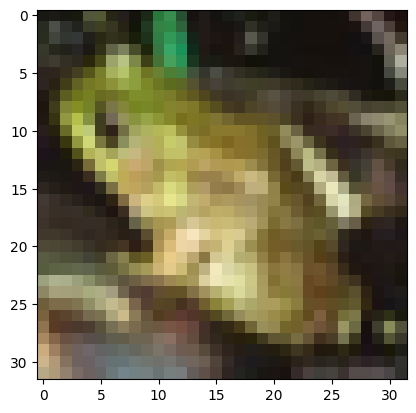

tensor([6])
frog
torch.Size([1, 3, 32, 32])


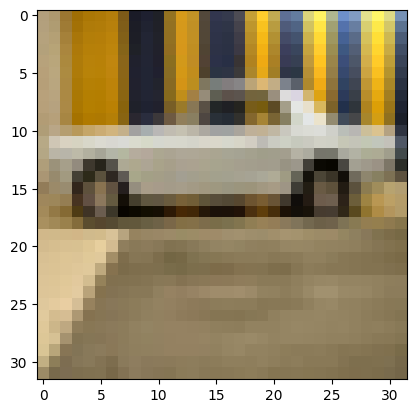

tensor([1])
car
torch.Size([1, 3, 32, 32])


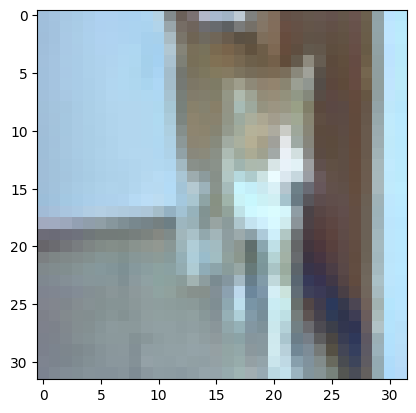

tensor([3])
cat
torch.Size([1, 3, 32, 32])


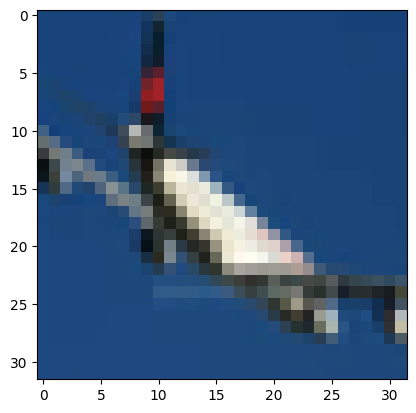

tensor([0])
plane
torch.Size([1, 3, 32, 32])


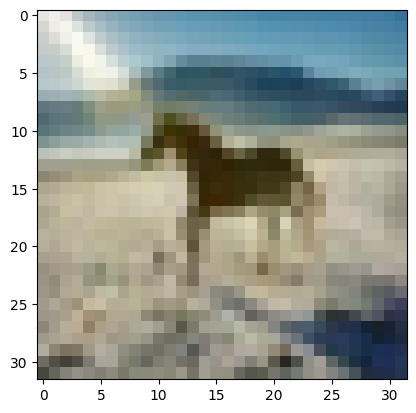

tensor([7])
horse
torch.Size([1, 3, 32, 32])


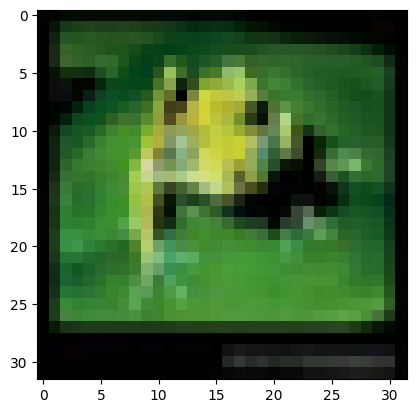

tensor([6])
frog
torch.Size([1, 3, 32, 32])


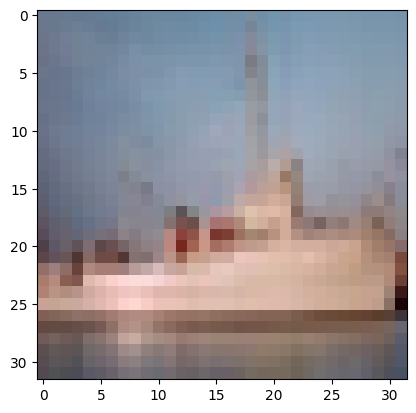

tensor([8])
ship
torch.Size([1, 3, 32, 32])


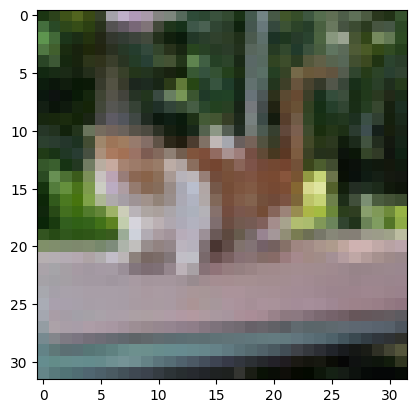

tensor([3])
cat
torch.Size([1, 3, 32, 32])


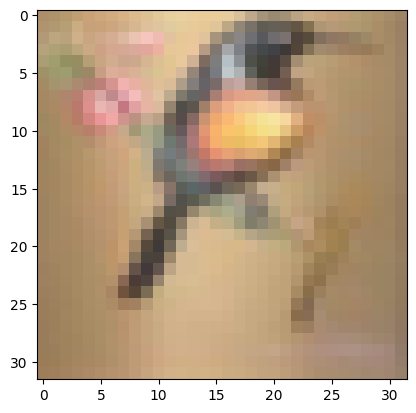

tensor([2])
bird
torch.Size([1, 3, 32, 32])


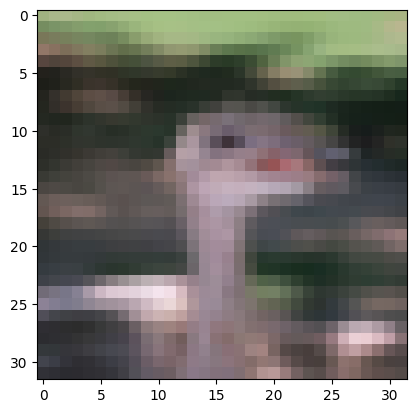

tensor([2])
bird
torch.Size([1, 3, 32, 32])


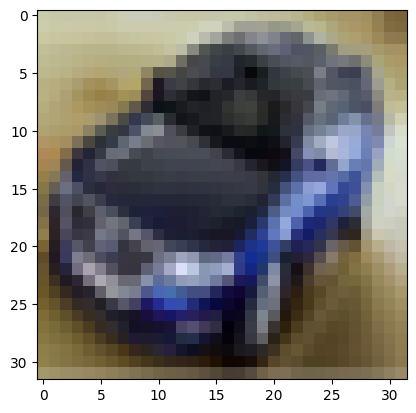

tensor([1])
car


In [4]:
# @title Loading CIFAR10 dataset

#reused code from the 5th lab

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

transform = transforms.ToTensor()

dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# for reproducibility
trainset, valset = torch.utils.data.random_split(dataset, [45000, 5000], generator=torch.Generator().manual_seed(42))

previewloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=True)

for i, sample in enumerate(previewloader):
  if i > 10:
    break
  x, y = sample
  print(x.shape)
  img = np.moveaxis(x.numpy()[0], 0, -1)
  plt.imshow(img)
  plt.show()
  print(y)
  print(classes[y.item()])

In [5]:
from torch.nn import ReLU, Softmax, Sequential, Linear, Conv2d, MaxPool2d, Flatten, AdaptiveAvgPool2d, Dropout, Dropout2d

def build_model(num_classes=10):
    model = Sequential(
        Conv2d(3, 32, 3, padding=1, bias=True), ReLU(),
        MaxPool2d(2),
        Conv2d(32, 64, 3, padding=1, bias=True), ReLU(),
        MaxPool2d(2),
        Conv2d(64, 128, 3, padding=1, bias=True), ReLU(),
        MaxPool2d(2),

        AdaptiveAvgPool2d(1),
        Flatten(),
        Linear(128, num_classes)
    )

    model_inference = Sequential(model, Softmax(dim=1))
    return model, model_inference

model, model_inference = build_model()

out = model_inference(torch.from_numpy(np.zeros([1, 3, 32, 32], dtype=np.float32)))
print(out.size())
print(out)
print(classes[out.argmax().item()])

torch.Size([1, 10])
tensor([[0.0966, 0.0937, 0.0937, 0.1090, 0.1053, 0.0924, 0.1015, 0.1076, 0.1024,
         0.0979]], grad_fn=<SoftmaxBackward0>)
cat


In [6]:
def one_epoch(model, loss, optimizer, dataloader_train, dataloader_val, verbose=True):
  train_losses = []
  val_losses = []

  model.train()
  for i, batch in enumerate(dataloader_train):
    x, y = batch[0].to(device), batch[1].to(device)
    optimizer.zero_grad()

    out = model(x)
    loss = ce_loss(out, y)
    loss.backward()
    train_losses.append(loss.item())
    optimizer.step()
    if i % 100 == 0 and verbose:
      print("Training loss at step {}: {}".format(i, loss.item()))

  model.eval()
  with torch.no_grad():
    correct = 0
    total = 0
    for i, batch in enumerate(dataloader_val):
      x, y = batch[0].to(device), batch[1].to(device)

      out = model(x)
      loss = ce_loss(out, y)
      acc = torch.sum(torch.argmax(out, dim=-1) == y)
      correct += acc.item()
      total += len(batch[1])
      val_losses.append(loss.item())

  val_acc = correct / total

  return np.mean(train_losses), np.mean(val_losses), val_acc

In [ ]:
transform1 = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

transform2 = transforms.Compose([
    transforms.RandomResizedCrop(32, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
])

transform3 = transforms.Compose([
    transforms.RandomAffine(
        degrees=20,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
        shear=10
    ),
    transforms.RandomPerspective(distortion_scale=0.4, p=0.5),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

Using device:  cuda:0
Trying augmentation setting: augmentation_easy
Val loss at epoch 0: 1.5545264634357137
Val acc at epoch 0: 0.4368
Val loss at epoch 1: 1.4588819932026469
Val acc at epoch 1: 0.4576
Val loss at epoch 2: 1.3166374848906401
Val acc at epoch 2: 0.5288
Val loss at epoch 3: 1.2474148060865462
Val acc at epoch 3: 0.5556
Val loss at epoch 4: 1.1879348971281842
Val acc at epoch 4: 0.5718
Val loss at epoch 5: 1.0954268984733873
Val acc at epoch 5: 0.6138
Val loss at epoch 6: 1.0898022864274919
Val acc at epoch 6: 0.6174
Val loss at epoch 7: 1.059718073932988
Val acc at epoch 7: 0.6242
Val loss at epoch 8: 0.9987527280096795
Val acc at epoch 8: 0.6446
Val loss at epoch 9: 0.9550526536953677
Val acc at epoch 9: 0.6596
Val loss at epoch 10: 1.0382527348342214
Val acc at epoch 10: 0.6404
Val loss at epoch 11: 0.9127467295546441
Val acc at epoch 11: 0.6746
Val loss at epoch 12: 0.8844795331453822
Val acc at epoch 12: 0.6948
Val loss at epoch 13: 0.9703461336102456
Val acc at epo

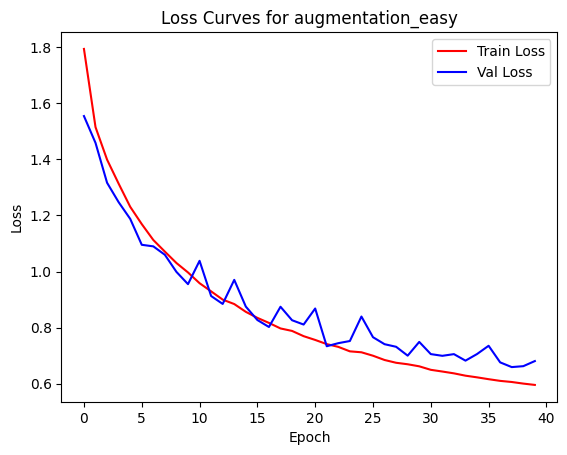

Trying augmentation setting: augmentation_medium
Val loss at epoch 0: 1.516978373952732
Val acc at epoch 0: 0.4508
Val loss at epoch 1: 1.4214688448389625
Val acc at epoch 1: 0.471
Val loss at epoch 2: 1.3100484210974093
Val acc at epoch 2: 0.5228
Val loss at epoch 3: 1.216870512552322
Val acc at epoch 3: 0.5598
Val loss at epoch 4: 1.0958908424255953
Val acc at epoch 4: 0.61
Val loss at epoch 5: 1.0792083375772852
Val acc at epoch 5: 0.6156
Val loss at epoch 6: 1.0705288671384192
Val acc at epoch 6: 0.6218
Val loss at epoch 7: 1.0581841392881552
Val acc at epoch 7: 0.6222
Val loss at epoch 8: 0.929548553410609
Val acc at epoch 8: 0.6762
Val loss at epoch 9: 0.9647134743678342
Val acc at epoch 9: 0.6596
Val loss at epoch 10: 0.9408190324427975
Val acc at epoch 10: 0.664
Val loss at epoch 11: 0.9155627141712578
Val acc at epoch 11: 0.6784
Val loss at epoch 12: 0.9823470899633541
Val acc at epoch 12: 0.6624
Val loss at epoch 13: 0.8796851048423986
Val acc at epoch 13: 0.6886
Val loss at 

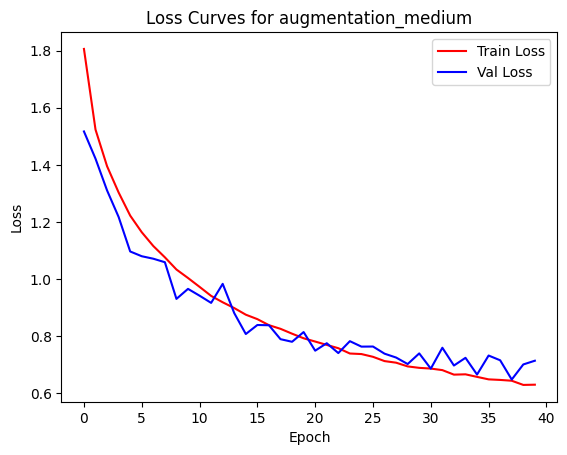

Trying augmentation setting: augmentation_finalBoss
Val loss at epoch 0: 1.667784244391569
Val acc at epoch 0: 0.391
Val loss at epoch 1: 1.5984089116381992
Val acc at epoch 1: 0.4332
Val loss at epoch 2: 1.472879262866488
Val acc at epoch 2: 0.479
Val loss at epoch 3: 1.4602667161613514
Val acc at epoch 3: 0.4904
Val loss at epoch 4: 1.248723613608415
Val acc at epoch 4: 0.544
Val loss at epoch 5: 1.1536020408770082
Val acc at epoch 5: 0.587
Val loss at epoch 6: 1.1421641665659132
Val acc at epoch 6: 0.6
Val loss at epoch 7: 1.0808093973026154
Val acc at epoch 7: 0.6236
Val loss at epoch 8: 1.1190926592061474
Val acc at epoch 8: 0.6036
Val loss at epoch 9: 1.067653566788716
Val acc at epoch 9: 0.6118
Val loss at epoch 10: 0.9960608843025888
Val acc at epoch 10: 0.645
Val loss at epoch 11: 0.9929285201297444
Val acc at epoch 11: 0.6512
Val loss at epoch 12: 0.9963043005603134
Val acc at epoch 12: 0.648
Val loss at epoch 13: 0.9797514536578185
Val acc at epoch 13: 0.655
Val loss at epoc

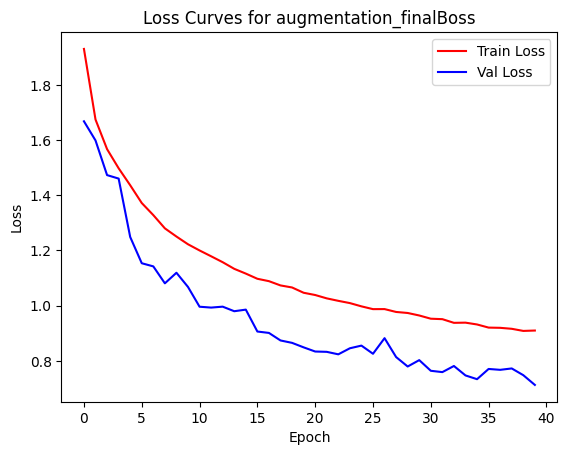

In [ ]:
configs = [{'name': 'augmentation_easy', 'augmentation': transform1},
           {'name': 'augmentation_medium', 'augmentation': transform2},
           {'name': 'augmentation_finalBoss', 'augmentation': transform3}
           ]

losses = {config['name']: ([], []) for config in configs}
accuracies = {config['name']: [] for config in configs}

batch_size = 32

dataloader_val = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

ce_loss = torch.nn.CrossEntropyLoss().to(device)

for config in configs:
    print(f"Trying augmentation setting: {config['name']}")

    aug_transforms = config['augmentation']
    dataset_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=aug_transforms)
    trainset_aug, _ = torch.utils.data.random_split(dataset_aug, [45000, 5000], generator=torch.Generator().manual_seed(42))
    dataloader_train = torch.utils.data.DataLoader(trainset_aug, batch_size=batch_size, shuffle=True)

    model, model_inference = build_model(num_classes=10)
    model.to(device)
    model_inference.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accs = []

    for e in range(40):
        train_loss, val_loss, val_acc = one_epoch(model, ce_loss, optimizer, dataloader_train, dataloader_val, False)

        print(f"Val loss at epoch {e}: {val_loss}")
        print(f"Val acc at epoch {e}: {val_acc}")

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_val_accs.append(val_acc)

    losses[config['name']][0].append(epoch_train_losses)
    losses[config['name']][1].append(epoch_val_losses)
    accuracies[config['name']].append(epoch_val_accs)

    plt.plot(epoch_train_losses, c='r', label='Train Loss')
    plt.plot(epoch_val_losses, c='b', label='Val Loss')
    plt.title(f"Loss Curves for {config['name']}")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [ ]:
import json

results_to_dump = {
    'losses': losses,
    'accuracies': accuracies
}

output_filename = 'augmentation_results.json'

with open(output_filename, 'w') as f:
    json.dump(results_to_dump, f)

print(f"Results dumped to {output_filename}")

Results dumped to augmentation_results.json


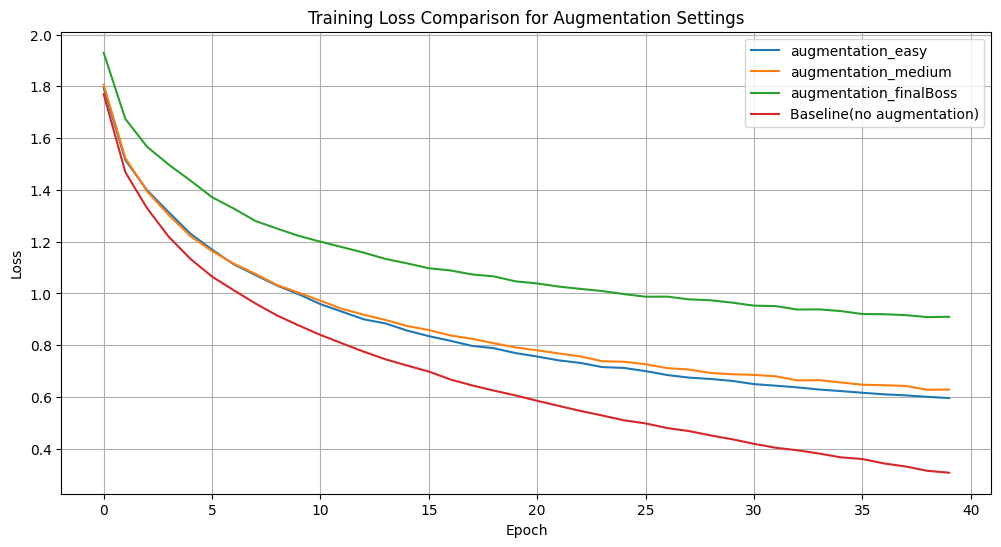

In [ ]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][0][0], label=optimizer_name['name'])

plt.plot(baseline_train_losses, label='Baseline(no augmentation)')

plt.title('Training Loss Comparison for Augmentation Settings')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

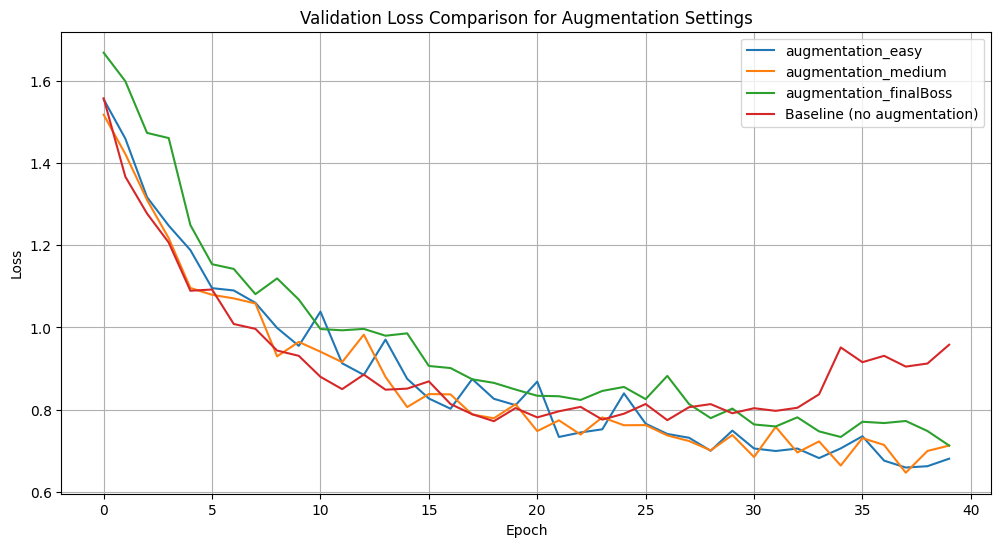

In [ ]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][1][0], label=optimizer_name['name'])

plt.plot(baseline_val_losses, label='Baseline (no augmentation)')

plt.title('Validation Loss Comparison for Augmentation Settings')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

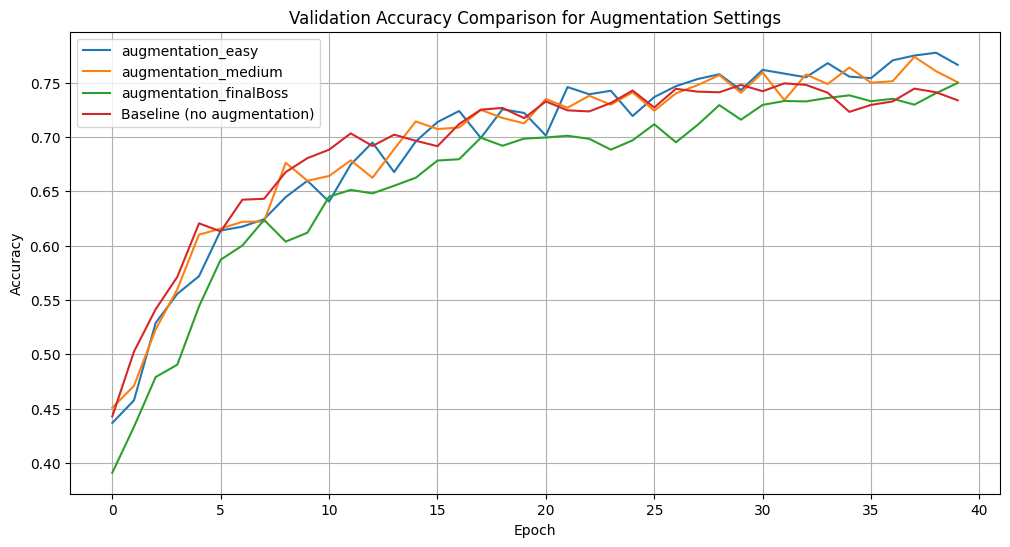

In [ ]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(accuracies[optimizer_name['name']][0], label=optimizer_name['name'])

plt.plot(baseline_val_accs, label='Baseline (no augmentation)')

plt.title('Validation Accuracy Comparison for Augmentation Settings')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

summary_data = {}

# Get baseline results
summary_data['Baseline (no augmentation)'] = {
    'Final Train Loss': baseline_train_losses[-1],
    'Final Val Loss': baseline_val_losses[-1],
    'Final Val Accuracy': baseline_val_accs[-1]
}

# Get results for each optimizer
for config in configs:
    summary_data[config['name']] = {
        'Final Train Loss': losses[config['name']][0][0][-1],
        'Final Val Loss': losses[config['name']][1][0][-1],
        'Final Val Accuracy': accuracies[config['name']][0][-1]
    }

summary_df = pd.DataFrame.from_dict(summary_data, orient='index')
display(summary_df)

,Final Train Loss,Final Val Loss,Final Val Accuracy
Baseline (no augmentation),0.307193,0.957867,0.7336
augmentation_easy,0.595666,0.680770,0.7662
augmentation_medium,0.628581,0.712674,0.7502
augmentation_finalBoss,0.909785,0.712767,0.7496


### Dropout on 1000 sample train set

In [7]:
transform1 = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

transform2 = transforms.Compose([
    transforms.RandomResizedCrop(32, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
])

transform3 = transforms.Compose([
    transforms.RandomAffine(
        degrees=20,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
        shear=10
    ),
    transforms.RandomPerspective(distortion_scale=0.4, p=0.5),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

Using device:  cuda:0
Trying augmentation setting: augmentation_easy
Val loss at epoch 0: 2.2924022129870583
Val acc at epoch 0: 0.11634693877551021
Val loss at epoch 10: 2.024142332238877
Val acc at epoch 10: 0.24759183673469387
Val loss at epoch 20: 1.8653363448521487
Val acc at epoch 20: 0.31316326530612243
Val loss at epoch 30: 1.7274513107678287
Val acc at epoch 30: 0.3607755102040816
Val loss at epoch 40: 1.6738666846142114
Val acc at epoch 40: 0.3873673469387755
Val loss at epoch 50: 1.598450344007258
Val acc at epoch 50: 0.4220408163265306
Val loss at epoch 60: 1.670976645524757
Val acc at epoch 60: 0.4048775510204082
Val loss at epoch 70: 1.644878797719435
Val acc at epoch 70: 0.4166326530612245
Val loss at epoch 80: 1.6197714674099306
Val acc at epoch 80: 0.4390816326530612
Val loss at epoch 90: 1.5660423641883363
Val acc at epoch 90: 0.45402040816326533
Val loss at epoch 100: 1.6145682604910498
Val acc at epoch 100: 0.46122448979591835
Val loss at epoch 110: 1.65627355577895

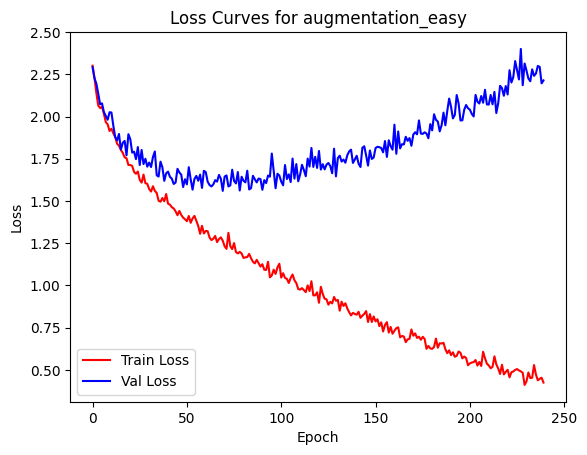

Trying augmentation setting: augmentation_medium
Val loss at epoch 0: 2.2131709836170503
Val acc at epoch 0: 0.17044897959183675
Val loss at epoch 10: 1.8933539248166444
Val acc at epoch 10: 0.30083673469387756
Val loss at epoch 20: 1.8309738399465776
Val acc at epoch 20: 0.34279591836734696
Val loss at epoch 30: 1.666756251228696
Val acc at epoch 30: 0.3974285714285714
Val loss at epoch 40: 1.6492817330298162
Val acc at epoch 40: 0.39371428571428574
Val loss at epoch 50: 1.5972234714902724
Val acc at epoch 50: 0.4214081632653061
Val loss at epoch 60: 1.6231100775554348
Val acc at epoch 60: 0.43451020408163266
Val loss at epoch 70: 1.5453187351749709
Val acc at epoch 70: 0.45010204081632654
Val loss at epoch 80: 1.675339900326791
Val acc at epoch 80: 0.435
Val loss at epoch 90: 1.6568631563656635
Val acc at epoch 90: 0.44626530612244897
Val loss at epoch 100: 1.6130309444183468
Val acc at epoch 100: 0.4556122448979592
Val loss at epoch 110: 1.7510391427471494
Val acc at epoch 110: 0.44

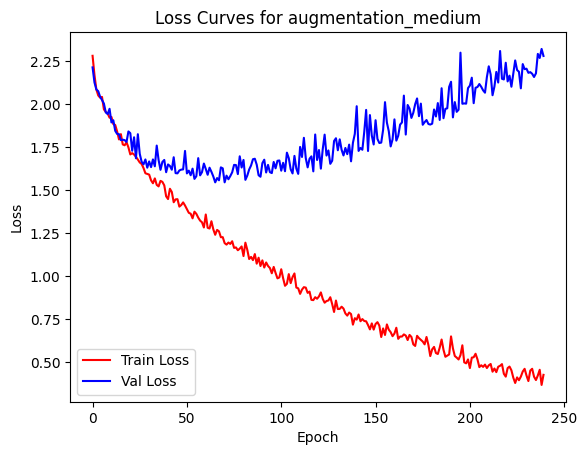

Trying augmentation setting: augmentation_finalBoss
Val loss at epoch 0: 2.2819819145352036
Val acc at epoch 0: 0.10257142857142858
Val loss at epoch 10: 2.002757134776825
Val acc at epoch 10: 0.23265306122448978
Val loss at epoch 20: 1.8332123290309708
Val acc at epoch 20: 0.30036734693877554
Val loss at epoch 30: 1.729674431191412
Val acc at epoch 30: 0.36006122448979594
Val loss at epoch 40: 1.6681593140640707
Val acc at epoch 40: 0.39148979591836736
Val loss at epoch 50: 1.6101515539009952
Val acc at epoch 50: 0.40922448979591836
Val loss at epoch 60: 1.6322743493489746
Val acc at epoch 60: 0.4160204081632653
Val loss at epoch 70: 1.5870023915257216
Val acc at epoch 70: 0.4270816326530612
Val loss at epoch 80: 1.587257342223399
Val acc at epoch 80: 0.4316938775510204
Val loss at epoch 90: 1.5358632182016696
Val acc at epoch 90: 0.44681632653061226
Val loss at epoch 100: 1.6285925328186848
Val acc at epoch 100: 0.43842857142857145
Val loss at epoch 110: 1.5431732512796517
Val acc at

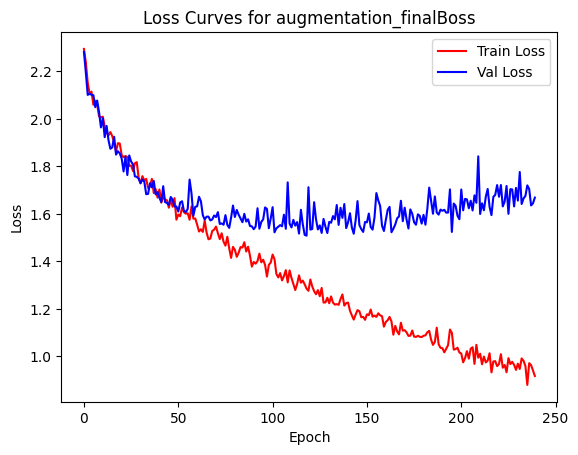

In [8]:
configs = [{'name': 'augmentation_easy', 'augmentation': transform1},
           {'name': 'augmentation_medium', 'augmentation': transform2},
           {'name': 'augmentation_finalBoss', 'augmentation': transform3}
           ]

losses = {config['name']: ([], []) for config in configs}
accuracies = {config['name']: [] for config in configs}

batch_size = 32

_, valset = torch.utils.data.random_split(dataset, [1000, 49000], generator=torch.Generator().manual_seed(42))
dataloader_val = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

ce_loss = torch.nn.CrossEntropyLoss().to(device)

for config in configs:
    print(f"Trying augmentation setting: {config['name']}")

    aug_transforms = config['augmentation']
    dataset_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=aug_transforms)
    trainset_aug, _ = torch.utils.data.random_split(dataset_aug, [1000, 49000], generator=torch.Generator().manual_seed(42))
    dataloader_train = torch.utils.data.DataLoader(trainset_aug, batch_size=batch_size, shuffle=True)

    model, model_inference = build_model(num_classes=10)
    model.to(device)
    model_inference.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accs = []

    for e in range(240):
        train_loss, val_loss, val_acc = one_epoch(model, ce_loss, optimizer, dataloader_train, dataloader_val, False)

        if e % 10 == 0:
          print(f"Val loss at epoch {e}: {val_loss}")
          print(f"Val acc at epoch {e}: {val_acc}")

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_val_accs.append(val_acc)

    losses[config['name']][0].append(epoch_train_losses)
    losses[config['name']][1].append(epoch_val_losses)
    accuracies[config['name']].append(epoch_val_accs)

    plt.plot(epoch_train_losses, c='r', label='Train Loss')
    plt.plot(epoch_val_losses, c='b', label='Val Loss')
    plt.title(f"Loss Curves for {config['name']}")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [9]:
import json

results_to_dump = {
    'losses': losses,
    'accuracies': accuracies
}

output_filename = 'augmentation_results_1k.json'

with open(output_filename, 'w') as f:
    json.dump(results_to_dump, f)

print(f"Results dumped to {output_filename}")

Results dumped to augmentation_results_1k.json


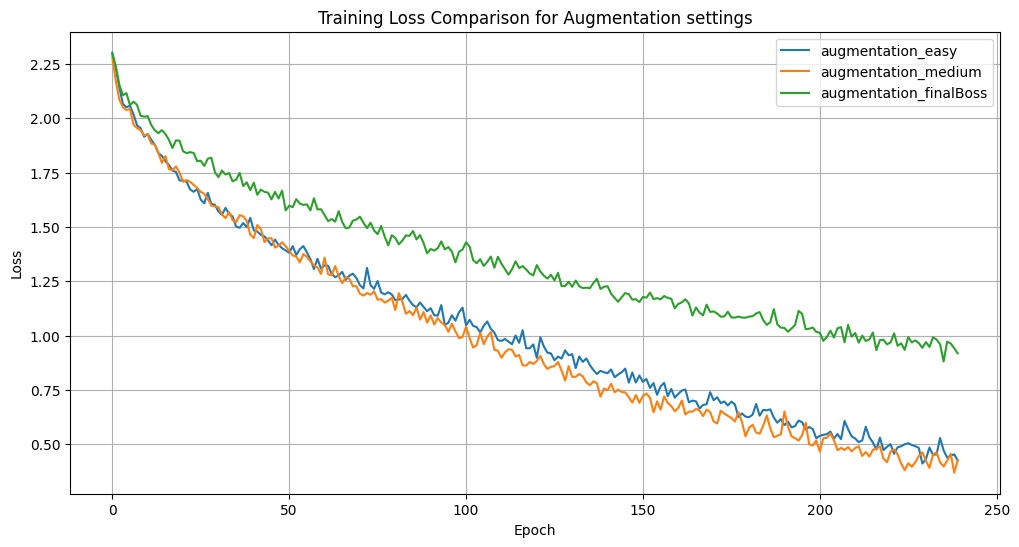

In [10]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][0][0], label=optimizer_name['name'])

#plt.plot(baseline_train_losses, label='Baseline(no dropout)')

plt.title('Training Loss Comparison for Augmentation settings')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

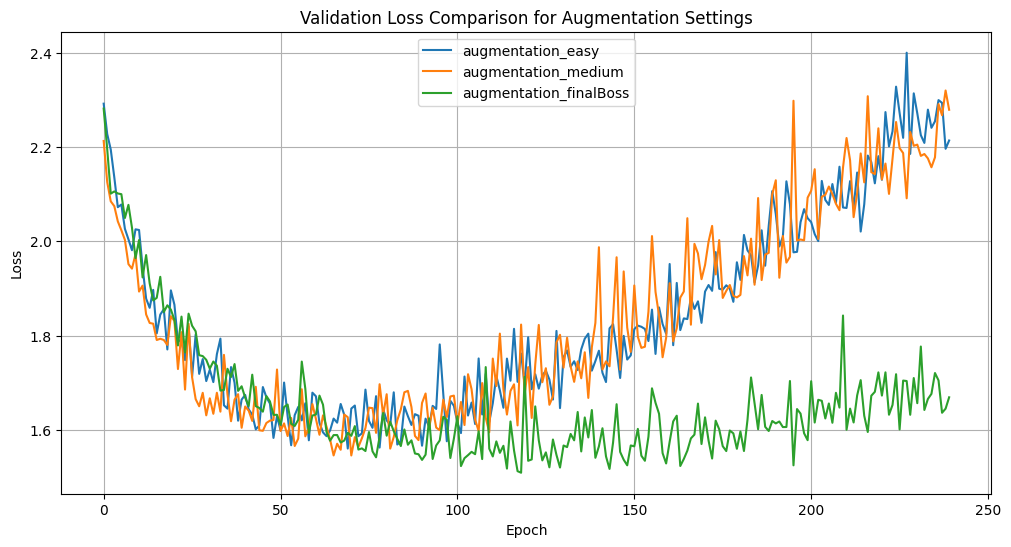

In [11]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][1][0], label=optimizer_name['name'])

#plt.plot(baseline_val_losses, label='Baseline (no dropoout)')

plt.title('Validation Loss Comparison for Augmentation Settings')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

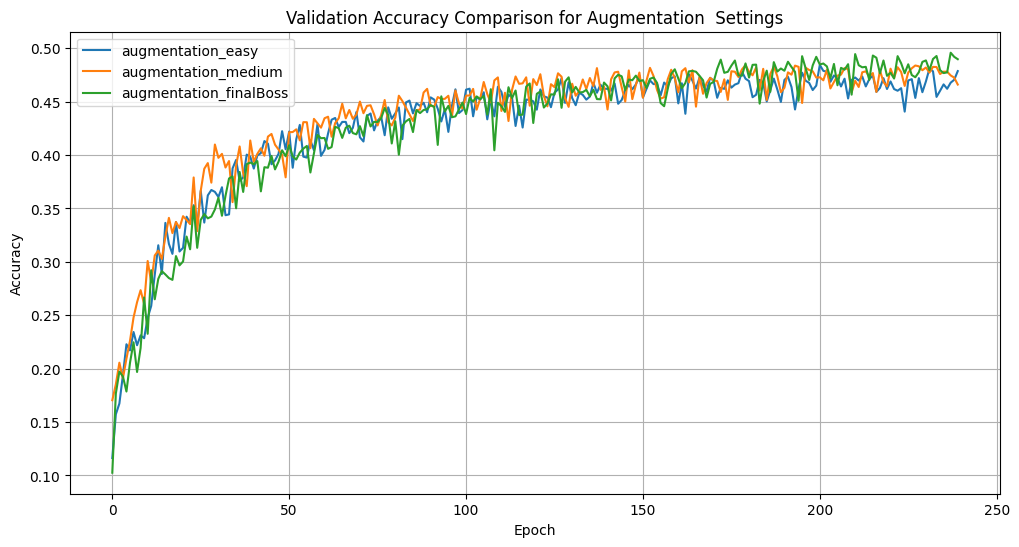

In [12]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(accuracies[optimizer_name['name']][0], label=optimizer_name['name'])

#plt.plot(baseline_val_accs, label='Baseline (no dropout)')

plt.title('Validation Accuracy Comparison for Augmentation  Settings')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
import pandas as pd

summary_data = {}

# Get baseline results
#summary_data['Baseline (no dropout)'] = {
#    'Final Train Loss': baseline_train_losses[-1],
#    'Final Val Loss': baseline_val_losses[-1],
#    'Final Val Accuracy': baseline_val_accs[-1]
#}

for config in configs:
    summary_data[config['name']] = {
        'Final Train Loss': losses[config['name']][0][0][-1],
        'Final Val Loss': losses[config['name']][1][0][-1],
        'Final Val Accuracy': accuracies[config['name']][0][-1]
    }

summary_df = pd.DataFrame.from_dict(summary_data, orient='index')
display(summary_df)

,Final Train Loss,Final Val Loss,Final Val Accuracy
augmentation_easy,0.424578,2.214187,0.478653
augmentation_medium,0.427136,2.279439,0.466061
augmentation_finalBoss,0.917791,1.668821,0.489796
